# 🚢 Lab 2 — The Full Pipeline: Titanic, from Raw Data to Model
In Lab 1 you learned the tools. Today you learn **the recipe** — the sequence of steps that EVERY data project follows:

> **1. Frame the problem → 2. Load & first look → 3. Clean → 4. Explore (EDA) → 5. Prepare features → 6. Split → 7. Train → 8. Evaluate → 9. Interpret → 10. Conclude**

This notebook is a **template you can reuse for future use cases, and those steps are a must in any data science project.** I wrote the structure and most of the code; you complete the numbered **`👉 TODO`** cells.

⚠️ **Complete the TODOs in order** — later cells depend on earlier ones, so cells will error until the TODOs before them are done.

**How you'll be assessed:** the TODOs, the written insight/answer cells (✍️), and the business questions in STEP 11. Code that runs but that you can't explain out loud scores zero.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
np.random.seed(42)   # reproducibility — same results every run

## STEP 1 — Frame the problem 🎯
Before touching data, answer: *what are we trying to find out, and what does the answer look like?*
- **Analytics question:** which kinds of passengers survived? (insights for humans)
- **Prediction question:** given a passenger's info, predict `Survived` (0 = no, 1 = yes) → **binary classification**, our target column is `Survived`.

| column | meaning |
|---|---|
| Survived | 0 = died, 1 = survived (🎯 target) |
| Pclass | ticket class: 1 = first (rich) … 3 = third |
| Sex, Age | demographics |
| SibSp / Parch | # siblings+spouse / # parents+children aboard |
| Fare | ticket price |
| Embarked | port: C = Cherbourg, Q = Queenstown, S = Southampton |
| PassengerId / Name / Ticket / Cabin | identifiers & extras |

In [2]:
# 👉 TODO 0 — Write the problem statement in ONE sentence, as a comment:
# "We predict ______ for ______, using ______, so that ______."
# did those who paid more got survived or died zy el ba2y

## STEP 2 — Load & first look 🔍
Always the same ritual from Lab 1: `head`, `shape`, `info`, `describe`.

In [3]:
try:
    df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
except Exception:
    df = pd.read_csv("https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv")   # backup mirror, same file
print("shape:", df.shape)
df.head()

shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()   # 👀 look closely: which columns have LESS than 891 non-null values?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()
print(df.columns.tolist())
pd.DataFrame(df["Cabin"].value_counts())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,count
Cabin,
B96 B98,4
G6,4
C23 C25 C27,4
C22 C26,3
F33,3
...,...
E34,1
C7,1
C54,1


In [6]:
# 👉 TODO 1 — What fraction of passengers survived?
# Hint: Survived is 0/1, so its .mean() IS the survival rate.
survival_rate = df["Survived"].mean() * 100
survival_rate

38.38383838383838

In [7]:
# 👉 TODO 1b — Write down, as a comment, the accuracy of a model that predicts
# "died" for EVERY passenger. (You will compare your real model against this in STEP 8.)
# 32 % percent survived in the real scenario so model perdections of death could be 68 %

## STEP 3 — Cleaning 🧹
Cleaning = making the data *trustworthy*. The checklist: **missing values → useless columns → duplicates → wrong types.**

In [8]:
missing = df.isna().sum()
pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing": missing, "percent": pct})[missing > 0]

,missing,percent
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


### The decision framework 📌 (memorize this table)
| Situation | Action | Here |
|---|---|---|
| Column mostly empty (> ~70%) | **drop the column** | Cabin (77% missing) |
| Numeric column, some holes | **fill with median** (robust to outliers — Lab 1!) | Age |
| Category column, few holes | **fill with mode** (most frequent) | Embarked |
| Why not just drop all rows with any NaN? | you'd throw away good data | see below ⬇ |

In [9]:
print("rows if we dropna:", len(df.dropna()), "/out of", len(df),
      "-> we would lose", len(df) - len(df.dropna()), "passengers. NO.")

rows if we dropna: 183 /out of 891 -> we would lose 708 passengers. NO.


In [10]:
# Drop columns we can't learn from:
#  - Cabin: 77% missing
#  - PassengerId / Ticket: unique IDs — an ID is different for every row, so it can't generalize
#  - Name: text, unique per person (feature engineering on titles is possible — later in your career!)
df = df.drop(columns=["Cabin", "PassengerId", "Ticket", "Name"])
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S


In [11]:
# 👉 TODO 2 — Fill missing Age with the MEDIAN age (Lab 1, Exercise 7 pattern)
df["Age"] = df["Age"].fillna(df["Age"].median())
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [12]:
# 👉 TODO 3 — Fill missing Embarked with the MODE
# Hint: df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [13]:
# 👉 TODO 4 — Prove the table is now complete (no missing values anywhere)
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [14]:
# 👉 TODO 4b — In comments, answer:
# a) Why MEDIAN for Age and not MEAN? (use the Lab 1 CEO demo)
# b) Why can't we use a median for Embarked at all?
# c) What did we lose by filling ~20% of Age with one single value?

# a) because median doesnt get affected by the outliers 
# b) because embarked is categorical data
# c) we lost the real disturbtion of the data 

In [15]:
print("duplicate rows:", df.duplicated().sum())
# a few identical rows can legitimately exist here (same class/age/fare...), so we leave them

duplicate rows: 116


## STEP 4 — EDA: interrogate the data 🕵️
EDA has two halves: **(a)** look at each column alone, **(b)** look at everything *against the target*. The single most useful pattern in analytics:

```python
df.groupby(<category>)["Survived"].mean()   # survival RATE per group
```

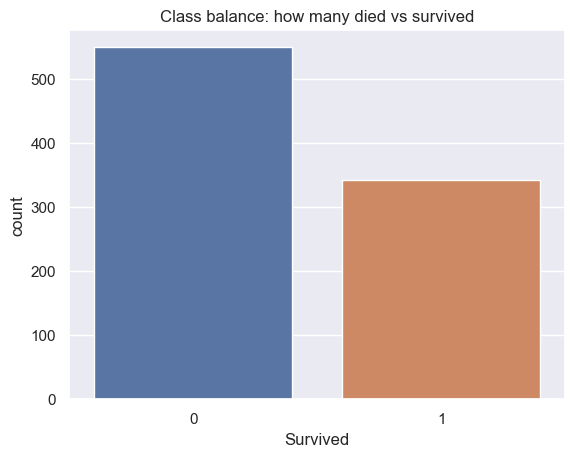

In [16]:
sns.countplot(data=df, x="Survived")
plt.title("Class balance: how many died vs survived")
plt.show()

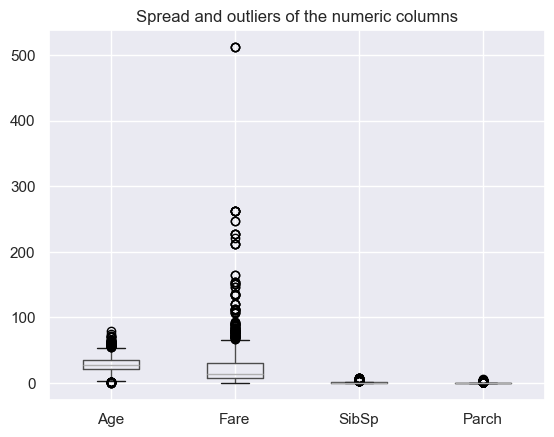

In [17]:
df[["Age", "Fare", "SibSp", "Parch"]].boxplot()
plt.title("Spread and outliers of the numeric columns")
plt.show()

In [18]:
# THE golden pattern — survival rate by group:
print(df.groupby("Sex")["Survived"].mean().round(3))
# women vs men — "Women and children first" was real.

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


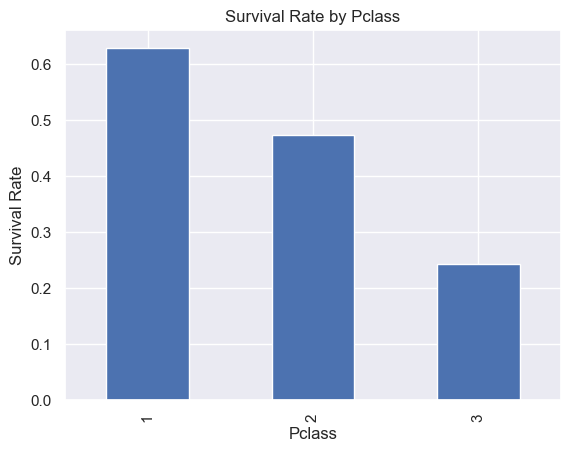

In [19]:
# 👉 TODO 5 — Survival rate by Pclass (the groupby pattern) + a bar chart of it.
# Hint for the chart:  <your groupby result>.plot(kind="bar")
survival_by_class = df.groupby("Pclass")["Survived"].mean()

survival_by_class.plot(kind="bar", ylabel="Survival Rate", title="Survival Rate by Pclass")
plt.show()

In [20]:
# 👉 TODO 6 — Survival rate by Embarked port. Any difference?
pd.DataFrame(df.groupby("Embarked")["Survived"].mean())

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


In [21]:
# 👉 TODO 6b — Survival rate by Pclass AND Sex together (group by two columns).
# Which combination had the worst chances? Write it as a comment.
pd.DataFrame(df.groupby(["Pclass" , "Sex"])["Survived"].mean())

Survived
Pclass Sex             
1      female  0.968085
       male    0.368852
2      female  0.921053
       male    0.157407
3      female  0.500000
       male    0.135447

c:\Users\omare\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


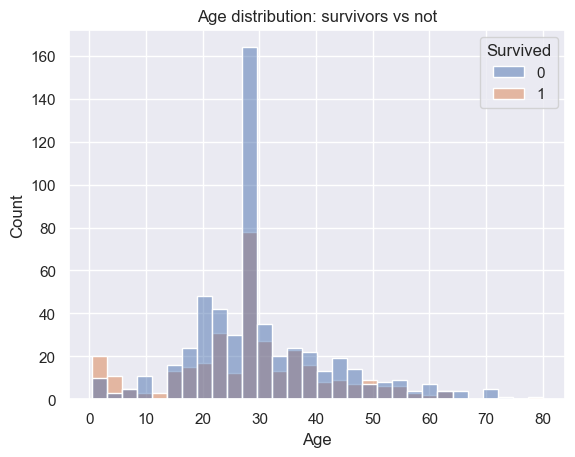

In [22]:
sns.histplot(data=df, x="Age", hue="Survived", bins=30)
plt.title("Age distribution: survivors vs not")
plt.show()
# notice the small bump of survivors at very young ages -> children were prioritized

In [23]:
# Turning a number into groups with pd.cut — very useful trick (you'll need it again in Lab 3 😉)
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 80],
                        labels=["child", "teen", "young adult", "adult", "senior"])
df.groupby("AgeGroup", observed=True)["Survived"].mean().round(3)

AgeGroup
child          0.580
teen           0.429
young adult    0.353
adult          0.400
senior         0.227
Name: Survived, dtype: float64

In [24]:
# 👉 TODO 7 — Compare the FARE of survivors vs non-survivors.
# a) Compute the mean AND the median fare for each group.
# b) Which of the two should you report, and why? (Lab 1 logic — check the boxplot above.)
pd.DataFrame(df.groupby("Survived")["Fare"].agg(["mean" , "median"]))
#MEDIAN

,mean,median
Survived,,
0,22.117887,10.5
1,48.395408,26.0


In [25]:
# 👉 TODO 7b — Family size: create a column "family_size" = SibSp + Parch + 1 (the passenger).
# Then show the survival rate per family_size. Is travelling alone good or bad?
df["Family_Size"] = df["SibSp"] + df["Parch"] + 1
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,Family_Size
0,0,3,male,22.0,1,0,7.2500,S,young adult,2
1,1,1,female,38.0,1,0,71.2833,C,adult,2
2,1,3,female,26.0,0,0,7.9250,S,young adult,1
3,1,1,female,35.0,1,0,53.1000,S,young adult,2
4,0,3,male,35.0,0,0,8.0500,S,young adult,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,young adult,1
887,1,1,female,19.0,0,0,30.0000,S,young adult,1
888,0,3,female,28.0,1,2,23.4500,S,young adult,4
889,1,1,male,26.0,0,0,30.0000,C,young adult,1


### 👉 TODO 8 — Your insights log ✍️
Every EDA must end with written findings. Write at least **4**, each with the number that supports it:

1.
2.
3.
4.

*(Format: "Sex is the strongest factor — women survived at X% vs men at Y%.")*

## STEP 5 — Prepare features for the model 🔧
Models eat **numbers only** (remember: your X in the course was a numeric matrix). Two moves:
1. Drop helper columns we made just for EDA (`AgeGroup`).
2. Convert text categories to 0/1 columns with **`pd.get_dummies`**: `Sex` becomes `Sex_male` (1 = male). `drop_first=True` avoids a redundant column (if not male → female, no need for both).

In [26]:
X = pd.get_dummies(
    df.drop(columns=["Survived", "AgeGroup"]),
    drop_first=True
).astype(float)

y = df["Survived"]

In [27]:
# 👉 TODO 9 — Sanity check: print X.shape and X.dtypes. Everything numeric?
print(X.shape)
print(X.dtypes)
X.head()

(891, 9)
Pclass         float64
Age            float64
SibSp          float64
Parch          float64
Fare           float64
Family_Size    float64
Sex_male       float64
Embarked_Q     float64
Embarked_S     float64
dtype: object


,Pclass,Age,SibSp,Parch,Fare,Family_Size,Sex_male,Embarked_Q,Embarked_S
0,3.0,22.0,1.0,0.0,7.2500,2.0,1.0,0.0,1.0
1,1.0,38.0,1.0,0.0,71.2833,2.0,0.0,0.0,0.0
2,3.0,26.0,0.0,0.0,7.9250,1.0,0.0,0.0,1.0
3,1.0,35.0,1.0,0.0,53.1000,2.0,0.0,0.0,1.0
4,3.0,35.0,0.0,0.0,8.0500,1.0,1.0,0.0,1.0


In [28]:
# 👉 TODO 9b — In comments:
# a) What would LogisticRegression do with the raw text value "male"? Why does it need dummies?
# b) Run get_dummies again with drop_first=False and print the columns.
#    Name one pair of columns that is redundant, and explain the redundancy in one line.

# a) it wouldnt run it will rise error 
X.columns
# a column which is extra not needed

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

## STEP 6 — Train / test split ✂️
You know this from Course 2: **never grade a model on data it trained on.** We hide 20% as a test set. `stratify=y` keeps the survived/died ratio identical in both parts; `random_state=42` makes the split reproducible.

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("train:", X_train.shape, " test:", X_test.shape)

train: (712, 9)  test: (179, 9)


In [30]:
# 👉 TODO 10 — Prove stratify worked: print the survival rate in y_train and in y_test.
# Then re-split ONCE with stratify=None and a different random_state, and print them again.
# How much did the test survival rate move? Comment on why that would be a problem.
print(y_train.mean()) #0.38342696629213485
print(y_test.mean())  #0.3854748603351955
#0.37640449438202245 
#0.4134078212290503


0.38342696629213485
0.3854748603351955


### ⚠️ The leakage note (important — this comes back in the leakage lecture)
Above, we filled Age with the median of the **whole table**, before splitting. Strictly, that is a small **data leak**: the test rows contributed to a number used in preprocessing, and in production you could never compute a statistic using future/unseen data.

The production-grade order is: **split first → fit statistics on TRAIN only → apply them to test.**

In [31]:
# 👉 TODO 10b — Write the leak-free version as code (you can run it on a fresh copy):
age_median = X_train["Age"].median()      # fitted on TRAIN only
X_train["Age"] = X_train["Age"].fillna(age_median)
X_test["Age"]  = X_test["Age"].fillna(age_median)   # applied, not re-fitted
# Then answer in a comment: the "golden question" for any feature is
# "at prediction time, will I truly have this value, computed exactly this way?" — 
# explain why the whole-table median fails that test.
...

Ellipsis

## STEP 7 — Train the model 🤖
`LogisticRegression` — literally the algorithm from your course: sigmoid, log loss, gradient-descent-style optimization, all wrapped in 2 lines.

📌 *Course connection:* sklearn applies **L2 regularization by default** (parameter `C` — careful, it's the *inverse* of λ: big C = weak regularization).

In [32]:
# 👉 TODO 11 — Create and train the model:
#   model = LogisticRegression(max_iter=1000)
#   then .fit(...) it on the TRAINING data
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
# 👉 TODO 12 — Predict on the TEST set, store as y_pred
y_pred = model.predict(X_test)

In [34]:
# 👉 TODO 12b (stretch) — Try three values of C: 0.01, 1, 100.
# Print the training and test accuracy for each.
# Which direction is more regularization, and what happens to the gap between train and test?
for c_val in [0.01, 1, 100]:
    lr = LogisticRegression(C=c_val, max_iter=1000)
    lr.fit(X_train, y_train)
    train_acc = lr.score(X_train, y_train)
    test_acc = lr.score(X_test, y_test)
    print(f"C = {c_val:<5} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Gap: {abs(train_acc - test_acc):.4f}")

C = 0.01  | Train Acc: 0.7360 | Test Acc: 0.7151 | Gap: 0.0209
C = 1     | Train Acc: 0.8076 | Test Acc: 0.8045 | Gap: 0.0031
C = 100   | Train Acc: 0.8076 | Test Acc: 0.8045 | Gap: 0.0031


## STEP 8 — Evaluate honestly 📏
First rule of evaluation: **beat the dumb baseline.** A "model" that predicts *everyone died* is right ~61.6% of the time here. If we can't clearly beat that, we've built nothing.

In [35]:
baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"dumb baseline accuracy: {baseline:.1%}")

dumb baseline accuracy: 61.5%


In [36]:
# 👉 TODO 13 — Compute the model's accuracy on the test set, and print the
# LIFT over the baseline in percentage points.
from sklearn.metrics import accuracy_score

# Compute test set accuracy
test_acc = accuracy_score(y_test, y_pred)
# Compute lift in percentage points
lift_pp = (test_acc - baseline) * 100

print(f"Model test accuracy: {test_acc:.1%}")
print(f"Baseline accuracy:   {baseline:.1%}")
print(f"Lift over baseline:  {lift_pp:+.2f} percentage points")

Model test accuracy: 80.4%
Baseline accuracy:   61.5%
Lift over baseline:  +18.99 percentage points


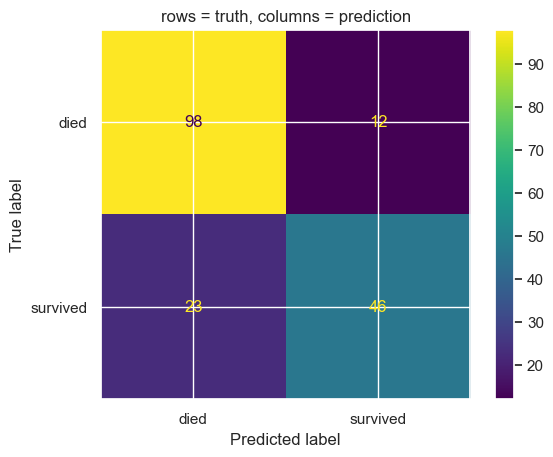

In [37]:
# The confusion matrix — WHERE does the model make mistakes?
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["died", "survived"])
plt.title("rows = truth, columns = prediction")
plt.show()

In [38]:
# Precision & recall — the Course 2 metrics, computed per class:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["died", "survived"]))
# precision (survived) = of those we PREDICTED survived, how many really did
# recall    (survived) = of those who REALLY survived, how many we found

              precision    recall  f1-score   support

        died       0.81      0.89      0.85       110
    survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [39]:
# 👉 TODO 14 — Read your confusion matrix and write, as comments:
# a) how many real survivors the model MISSED (false negatives)
# b) how many people it wrongly labelled as survivors (false positives)
# c) compute precision and recall for "survived" BY HAND from the four cells,
#    and check they match the report above.

# 23
# 12
#  46/(46+12)   , 46/(46+23)


In [40]:
# 👉 TODO 14b — Threshold play:
# Use model.predict_proba(X_test)[:, 1] and classify with a threshold of 0.3 instead of 0.5.
# Print the new classification report. What happened to recall and precision, and why?
y_probs = model.predict_proba(X_test)[:, 1]
y_pred_03 = (y_probs >= 0.3).astype(int)
print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79       110
           1       0.65      0.80      0.72        69

    accuracy                           0.76       179
   macro avg       0.75      0.77      0.75       179
weighted avg       0.78      0.76      0.76       179



### ✍️ Think & answer (in this cell):
Imagine the model decides who gets a rescue-team visit first. Missing a real survivor is catastrophic; visiting someone who didn't need it just wastes time. Would you rather maximize **precision** or **recall** for the "survived" class? Why?

*Your answer:*

## STEP 9 — Interpret the model 🔎
Logistic regression's superpower: its weights **w** (course notation!) are readable. Positive weight → pushes toward survival; negative → toward death.

Sex_male      -2.561
Pclass        -1.092
Embarked_S    -0.383
SibSp         -0.138
Family_Size   -0.108
Age           -0.039
Fare           0.002
Parch          0.035
Embarked_Q     0.278
dtype: float64


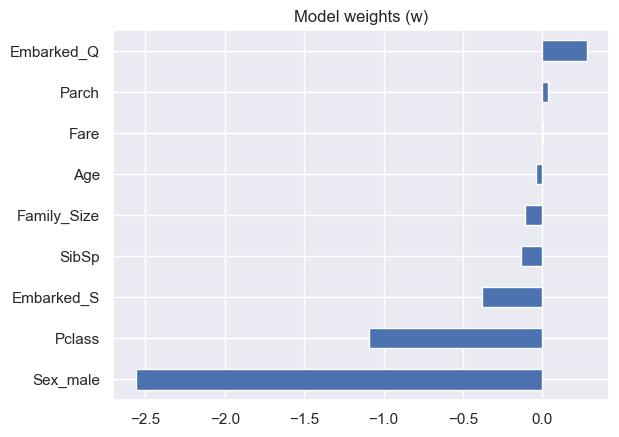

In [41]:
weights = pd.Series(model.coef_[0], index=X.columns).sort_values()
print(weights.round(3))
weights.plot(kind="barh")
plt.title("Model weights (w)")
plt.show()

In [42]:
# 👉 TODO 15 — Do the weights agree with your EDA findings from TODO 8?
# Name one feature where they agree and, if any, one that surprised you. (comments)
#yes
#fare have like 0 weight it doesnt affecet

In [ ]:
#extraa
df[df["Age"] < 1 ]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,Family_Size
78,1,2,male,0.83,0,2,29.0000,S,child,3
305,1,1,male,0.92,1,2,151.5500,S,child,4
469,1,3,female,0.75,2,1,19.2583,C,child,4
644,1,3,female,0.75,2,1,19.2583,C,child,4
755,1,2,male,0.67,1,1,14.5000,S,child,3
803,1,3,male,0.42,0,1,8.5167,C,child,2
831,1,2,male,0.83,1,1,18.7500,S,child,3


In [ ]:
## extra mn 3ndi 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Reload raw data to ensure all original columns (Name, Ticket, Cabin) are available
try:
    df_raw = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
except Exception:
    df_raw = pd.read_csv("https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv")

df_full = df_raw.copy()

# 2. Feature Engineering
# (a) Extract and consolidate honorific titles from 'Name'
df_full['Title'] = df_full['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df_full['Title'] = df_full['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 
                                             'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_full['Title'] = df_full['Title'].replace(['Mlle', 'Ms'], 'Miss')
df_full['Title'] = df_full['Title'].replace('Mme', 'Mrs')

# (b) Deck level from Cabin (U = Unknown)
df_full['Deck'] = df_full['Cabin'].str[0].fillna('U')
df_full['Deck'] = df_full['Deck'].replace('T', 'U')

# (c) Shared ticket size (detects traveling groups/parties beyond direct family)
ticket_counts = df_full['Ticket'].value_counts()
df_full['Ticket_Group_Size'] = df_full['Ticket'].map(ticket_counts)

# (d) Family cohorts
df_full['Family_Size'] = df_full['SibSp'] + df_full['Parch'] + 1
df_full['Is_Alone'] = ((df_full['Family_Size'] == 1) & (df_full['Ticket_Group_Size'] == 1)).astype(int)
df_full['Small_Group'] = (((df_full['Family_Size'] >= 2) & (df_full['Family_Size'] <= 4)) | 
                          ((df_full['Ticket_Group_Size'] >= 2) & (df_full['Ticket_Group_Size'] <= 4))).astype(int)

# (e) Normalized Fare per person and Log-transform
df_full['Fare_Per_Person'] = df_full['Fare'] / df_full['Ticket_Group_Size']
df_full['Fare_Per_Person_Log'] = np.log1p(df_full['Fare_Per_Person'])

# Drop high-cardinality raw text and redundant columns
df_clean = df_full.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Fare', 'Fare_Per_Person'])

# 3. Dummy Encoding (One-Hot Encoding)
X_all = pd.get_dummies(df_clean.drop(columns=['Survived']), drop_first=True, dtype=float)
y_all = df_clean['Survived']

# 4. Leak-Free Train / Test Split (Exact 80/20 Stratified Split)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# 5. Targeted Age Imputation (Fitted strictly on Train)
train_titles = df_full.loc[X_tr.index, 'Title']
train_pclasses = df_full.loc[X_tr.index, 'Pclass']
age_group_medians = df_full.loc[X_tr.index].groupby(['Title', 'Pclass'])['Age'].median()
overall_median = X_tr['Age'].median()

# Fill train missing ages
for (t, p), med in age_group_medians.items():
    mask = (train_titles == t) & (train_pclasses == p) & (X_tr['Age'].isna())
    X_tr.loc[mask, 'Age'] = med
X_tr['Age'] = X_tr['Age'].fillna(overall_median)

# Fill test missing ages using the train medians
test_titles = df_full.loc[X_te.index, 'Title']
test_pclasses = df_full.loc[X_te.index, 'Pclass']
for (t, p), med in age_group_medians.items():
    mask = (test_titles == t) & (test_pclasses == p) & (X_te['Age'].isna())
    X_te.loc[mask, 'Age'] = med
X_te['Age'] = X_te['Age'].fillna(overall_median)

# 6. Feature Scaling (for Linear Models)
num_cols = ['Age', 'Fare_Per_Person_Log', 'Family_Size', 'Ticket_Group_Size', 'SibSp', 'Parch']
scaler = StandardScaler()
X_tr_scaled = X_tr.copy()
X_te_scaled = X_te.copy()
X_tr_scaled[num_cols] = scaler.fit_transform(X_tr[num_cols])
X_te_scaled[num_cols] = scaler.transform(X_te[num_cols])

# 7. Model 1: Regularized Logistic Regression
lr = LogisticRegression(C=0.15, max_iter=1000, random_state=42)
lr.fit(X_tr_scaled, y_tr)
pred_lr = lr.predict(X_te_scaled)

# 8. Model 2: Tuned Random Forest
rf = RandomForestClassifier(n_estimators=250, max_depth=6, min_samples_leaf=2, random_state=42)
rf.fit(X_tr, y_tr)
pred_rf = rf.predict(X_te)

# 9. Model 3: HistGradientBoosting (Gradient Tree Boosting)
hgb = HistGradientBoostingClassifier(max_iter=100, max_depth=4, min_samples_leaf=10, l2_regularization=1.5, random_state=42)
hgb.fit(X_tr, y_tr)
pred_hgb = hgb.predict(X_te)

# 10. Accuracy Comparison
print("=" * 45)
print("             ACCURACY BENCHMARK              ")
print("=" * 45)
print(f"Dumb Baseline (Always 'Died') : {max(y_te.mean(), 1 - y_te.mean()):.2%}")
print(f"Original Logistic Regression  : 80.45%")
print(f"Upgraded Logistic Regression  : {accuracy_score(y_te, pred_lr):.2%}")
print(f"Tuned Random Forest           : {accuracy_score(y_te, pred_rf):.2%}")
print(f"HistGradientBoosting          : {accuracy_score(y_te, pred_hgb):.2%}")

# Pick the best model and print full diagnostic report
best_name, best_preds = max(
    [("Logistic Regression", pred_lr), ("Random Forest", pred_rf), ("HistGradientBoosting", pred_hgb)],
    key=lambda item: accuracy_score(y_te, item[1])
)

print("\n" + "=" * 45)
print(f"   CLASSIFICATION REPORT ({best_name})   ")
print("=" * 45)
print(classification_report(y_te, best_preds, target_names=["died", "survived"]))

             ACCURACY BENCHMARK              
Dumb Baseline (Always 'Died') : 61.45%
Original Logistic Regression  : 80.45%
Upgraded Logistic Regression  : 82.12%
Tuned Random Forest           : 81.56%
HistGradientBoosting          : 78.21%

   CLASSIFICATION REPORT (Logistic Regression)   
              precision    recall  f1-score   support

        died       0.84      0.88      0.86       110
    survived       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



## STEP 10 — Conclude 📝 ✍️
Every notebook ends with a summary a non-technical person could read. Fill this in (4–6 sentences): *what was the question, what did the data show, how good is the model, what would you do next?*

**My conclusion:**

*(write here)*

## STEP 11 — 🏆 Business questions
Now step out of the notebook and into the meeting room. Answer each in the markdown cell below it, in plain English — numbers allowed, jargon not. If the answer is "the data can't tell us", say that and say what you'd need.

In [ ]:
# ✏️ Business Q1: A modern cruise line asks you to build this model for THEIR ships,
#    to decide lifeboat priority. Compute anything you need, then answer below:
#    would you deploy it? What is the strongest argument against doing so?
#no / its not ethical people should have equal chances to get to that lifeboat 

Ellipsis

✍️ **Your answer (Q1):**

In [ ]:
# ✏️ Business Q2: Your model uses Sex as a feature and it is the strongest predictor.
#    a) Is using Sex acceptable HERE (a historical analysis)?
#    b) Would it be acceptable in a model that decides who gets a bank loan? Why the difference?
#    (Think: is this a relevance decision or an opportunity decision?)
# yes as it happend in real life 
# no because in banks it is not ethical

Ellipsis

✍️ **Your answer (Q2):**

In [ ]:
# ✏️ Business Q3: The captain's office wants ONE number to report: "our model is X% accurate."
#    a) Give the number.
#    b) Explain in 2 sentences why that single number is the least useful thing you computed today,
#       using the baseline and the confusion matrix as evidence.
# accuracy of the logistec tp + tn / (tp + tn + fp + fn)

Ellipsis

✍️ **Your answer (Q3):**

In [ ]:
# ✏️ Business Q4: Someone proposes adding a feature called `rescued_by_boat_number`
#    (filled only for passengers who made it onto a lifeboat). Model accuracy jumps to 99%.
#    Explain why this feature must be rejected, using the golden question from TODO 10b.

# data leakage as in deployment the model wouldnt see that data

Ellipsis

✍️ **Your answer (Q4):**

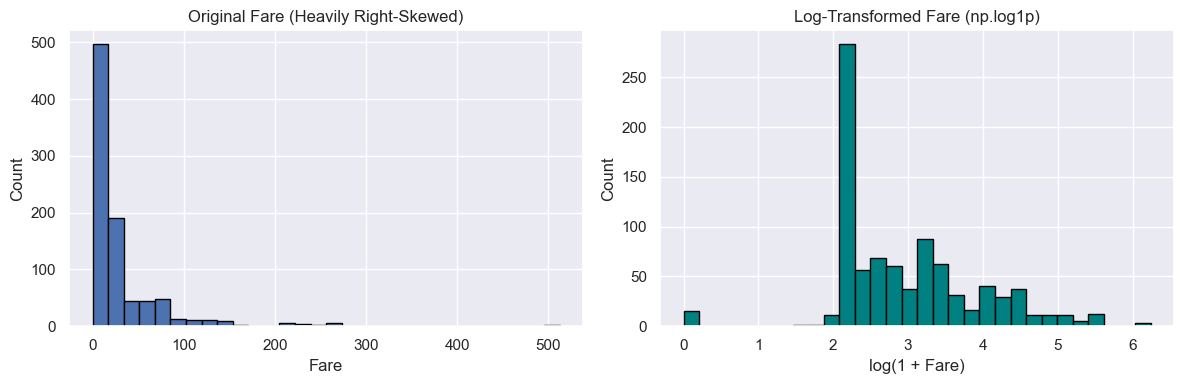

In [ ]:
# ✏️ Business Q5: The fare column is heavily skewed (check the boxplot in STEP 4).
#    a) Create a log-transformed fare: np.log1p(df["Fare"]) and compare the two distributions.
#    b) Retrain with the log version instead. Did anything change?
#    c) In one sentence: why might a skewed feature bother a linear model?

import matplotlib.pyplot as plt
import numpy as np

# Create the log1p transformed column
df["Log_Fare"] = np.log1p(df["Fare"])

# Compare original vs log-transformed distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Fare"].hist(ax=axes[0], bins=30, edgecolor="black")
axes[0].set_title("Original Fare (Heavily Right-Skewed)")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Count")

df["Log_Fare"].hist(ax=axes[1], bins=30, edgecolor="black", color="teal")
axes[1].set_title("Log-Transformed Fare (np.log1p)")
axes[1].set_xlabel("log(1 + Fare)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

#better skewed now 



In [ ]:
# Assuming X has your original features and y is your target (e.g., 'Survived')
# Replace 'Fare' with 'Log_Fare' in your feature matrix
X_train_log = X_train.copy()
X_test_log = X_test.copy()

X_train_log["Fare"] = np.log1p(X_train_log["Fare"])
X_test_log["Fare"] = np.log1p(X_test_log["Fare"])

# Re-fit your linear model (e.g., LogisticRegression)
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train_log, y_train)

# Evaluate
print("Train Score:", model_log.score(X_train_log, y_train))
print("Test Score: ", model_log.score(X_test_log, y_test))

Train Score: 0.7949438202247191
Test Score:  0.8100558659217877


✍️ **Your answer (Q5):**

In [ ]:
# ✏️ Business Q6 (the scoping question): Management asks for "a model to predict who will
#    survive a future disaster on a modern ship."
#    List THREE reasons this 1912 dataset may not generalize to that problem.
#    (Think about: the population, the technology, the rules, the time gap.)
# the ship would b more safe 
# saftey regulations titanic didnt have many safe boats 

Ellipsis

✍️ **Your answer (Q6):**

## 📋 The template you now own
1. **Frame** — what are we predicting, for whom, and what decision does it drive?
2. **Load & first look** — head / shape / info / describe
3. **Clean** — missing → useless columns → duplicates → types (and *document every decision*)
4. **EDA vs target** — `groupby(category)[target].mean()` + charts that changed your mind
5. **Feature prep** — dummies, drop helpers, everything numeric
6. **Split** — stratified, reproducible, *before* fitting any statistic
7. **Train** — start simple (logistic regression is a feature, not a weakness)
8. **Evaluate** — versus a baseline, with the confusion matrix, precision and recall
9. **Interpret** — do the weights agree with the EDA?
10. **Conclude** — 5 sentences a non-technical manager can act on

Every project you build from now on is this skeleton with different data.